# Test: Harmonic decomposition on synthetic propagating plane waves

**Goal.** Validate the per-pixel harmonic algorithm from `harmonic-cos.ipynb` against data with a *known* answer.

We build two synthetic `50 x 50 x 24` (2-year monthly) datasets containing **propagating plane waves** at a fixed angle theta:

* **(i)** annual only  (period P = 12 months)
* **(ii)** annual + biannual  (P = 12 and P = 6 months)

A plane wave `A*cos(k*(x*cos(theta) + y*sin(theta)) - omega*t)` is, at any *fixed* pixel, a pure sinusoid in time whose **phase depends on the pixel location**. So a correct per-pixel harmonic fit must recover:

* a **uniform amplitude** equal to the injected `A`, and
* a **phase that ramps linearly in space** along the propagation direction theta (the phase gradient *is* the propagation).

We also expect the **4-month harmonic amplitude to be ~0** everywhere, since no 4-month signal was injected.

No noise is added, so recovery should be essentially exact (R^2 ~ 1).

## Section A - Synthetic data generation

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---- grid definition -------------------------------------------------------
n_lat, n_lon, n_time = 50, 50, 24

# synthetic lat/lon box
lats = np.arange(n_lat, dtype=float)          # 0 .. 49
lons = np.arange(n_lon, dtype=float)          # 0 .. 49
months = pd.date_range('2003-01-01', periods=n_time, freq='MS')

t = np.arange(n_time)                          # 0 .. 23 (month index)
XX, YY = np.meshgrid(lons, lats)               # shape (n_lat, n_lon)

# ---- propagation geometry --------------------------------------------------
theta = np.deg2rad(30.0)                        # propagation angle
# spatial projection of each pixel onto the propagation direction
proj = XX * np.cos(theta) + YY * np.sin(theta)  # (n_lat, n_lon)

# choose k so ~1.5 wavelengths span the projected extent of the grid
n_wavelengths = 3
proj_span = proj.max() - proj.min()
k = 2 * np.pi * n_wavelengths / proj_span       # spatial wavenumber

print(f'grid            : {n_lat} lat x {n_lon} lon x {n_time} months')
print(f'theta           : {np.rad2deg(theta):.1f} deg')
print(f'proj span       : {proj_span:.2f}')
print(f'wavenumber k    : {k:.4f}  (~{n_wavelengths} wavelengths across grid)')

grid            : 50 lat x 50 lon x 24 months
theta           : 30.0 deg
proj span       : 66.94
wavenumber k    : 0.1408  (~1.5 wavelengths across grid)


In [ ]:
# ---- injected (ground-truth) parameters ------------------------------------
A12 = 1.0    # annual   amplitude
A6  = 0.5    # biannual amplitude  (only used in dataset ii)

omega12 = 2 * np.pi / 12.0   # annual   angular frequency (per month)
omega6  = 2 * np.pi / 6.0    # biannual angular frequency

# spatial phase offset of each pixel (this is what the decomposition should recover)
# for a term A*cos(k*proj - omega*t) = A*cos(omega*t - k*proj) reversed ->
# at fixed pixel: A*cos(omega*t - phi) with phi = k*proj  (cosine convention)
phi_true = (k * proj) % (2 * np.pi)              # (n_lat, n_lon), radians in [0, 2pi)

def plane_wave(A, omega):
    """Propagating plane wave field, shape (n_time, n_lat, n_lon).
    A*cos(k*proj - omega*t): a high-value band sweeps across the grid at angle theta."""
    tt = t[:, None, None]                        # (n_time,1,1)
    return A * np.cos(k * proj[None, :, :] - omega * tt)

# ---- dataset (i): annual only ----------------------------------------------
field_i = plane_wave(A12, omega12)

# ---- dataset (ii): annual + biannual ---------------------------------------
field_ii = plane_wave(A12, omega12) + plane_wave(A6, omega6)

coords = {'time': months, 'lat': lats, 'lon': lons}
da_i  = xr.DataArray(field_i,  dims=('time','lat','lon'), coords=coords, name='signal_annual')
da_ii = xr.DataArray(field_ii, dims=('time','lat','lon'), coords=coords, name='signal_annual_biannual')

print('dataset (i)  annual only          :', da_i.shape,  'range', float(da_i.min()),  '->', float(da_i.max()))
print('dataset (ii) annual + biannual    :', da_ii.shape, 'range', float(da_ii.min()), '->', float(da_ii.max()))
print()
print('INJECTED ground truth:')
print(f'  annual   amplitude A12 = {A12}   (uniform everywhere)')
print(f'  biannual amplitude A6  = {A6}    (dataset ii only)')
print(f'  4-month  amplitude     = 0       (should be recovered as ~0)')
print(f'  phi_true (annual) ranges {np.rad2deg(phi_true.min()):.1f} -> {np.rad2deg(phi_true.max()):.1f} deg across the grid')

dataset (i)  annual only          : (24, 50, 50) range -1.0 -> 1.0
dataset (ii) annual + biannual    : (24, 50, 50) range -1.5 -> 1.5

INJECTED ground truth:
  annual   amplitude A12 = 1.0   (uniform everywhere)
  biannual amplitude A6  = 0.5    (dataset ii only)
  4-month  amplitude     = 0       (should be recovered as ~0)
  phi_true (annual) ranges 0.0 -> 359.9 deg across the grid


## Section B - Animation of the propagating signals

Each frame is one month. Watch the high-value band march across the grid at 30 deg - the same high signal is handed from one set of grid cells to the next, frame by frame.

In [ ]:
import os
import matplotlib.animation as animation
from IPython.display import Image, display

OUT_DIR = '../Figures'
os.makedirs(OUT_DIR, exist_ok=True)

def animate_field(da, title, fname, vmin=None, vmax=None):
    data = da.values
    if vmin is None: vmin = float(np.nanmin(data))
    if vmax is None: vmax = float(np.nanmax(data))
    fig, ax = plt.subplots(figsize=(5.5, 5))
    pcm = ax.pcolormesh(lons, lats, data[0], cmap='RdBu_r', vmin=vmin, vmax=vmax, shading='nearest')
    fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04, label='signal')
    ax.set_xlabel('lon index'); ax.set_ylabel('lat index')
    ttl = ax.set_title(f'{title}\nmonth 1 / {data.shape[0]}')

    def update(i):
        pcm.set_array(data[i].ravel())
        ttl.set_text(f'{title}\nmonth {i+1} / {data.shape[0]}')
        return pcm, ttl

    anim = animation.FuncAnimation(fig, update, frames=data.shape[0], interval=250, blit=False)
    out = os.path.join(OUT_DIR, fname)
    anim.save(out, writer=animation.PillowWriter(fps=4))
    plt.close(fig)
    print('saved ->', out)
    return out

out_i  = animate_field(da_i,  'Dataset (i): annual propagating wave (theta=30 deg)',           'synthetic_annual.gif')
out_ii = animate_field(da_ii, 'Dataset (ii): annual + biannual propagating wave (theta=30 deg)','synthetic_annual_biannual.gif')

saved -> ../Figures\synthetic_annual.gif


saved -> ../Figures\synthetic_annual_biannual.gif


Dataset (i): annual only


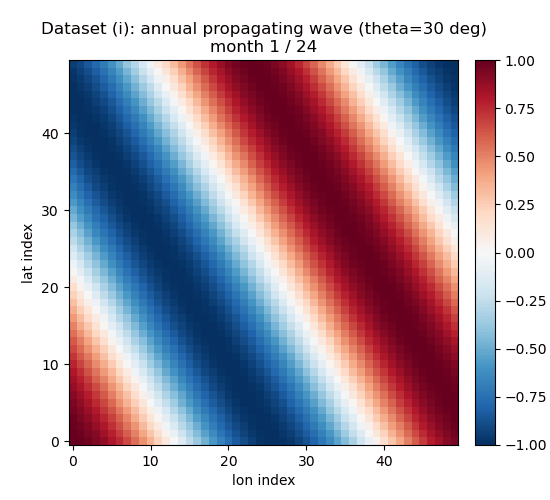

Dataset (ii): annual + biannual


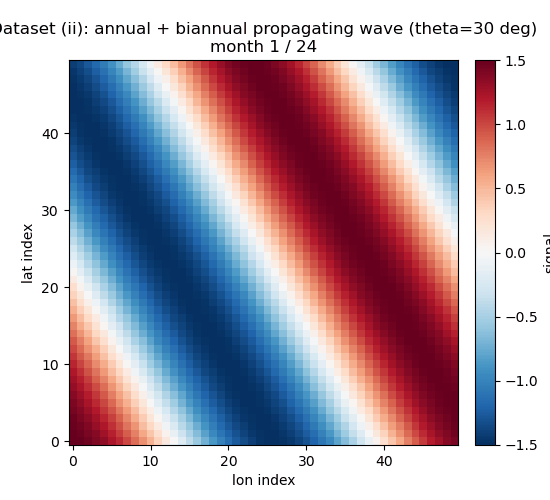

In [ ]:
# display the animations inline
print('Dataset (i): annual only'); display(Image(filename=out_i))
print('Dataset (ii): annual + biannual'); display(Image(filename=out_ii))

## Section C - Harmonic decomposition (code copied from harmonic-cos.ipynb)

The block below is the harmonic-regression algorithm from `harmonic-cos.ipynb`, applied here to the synthetic field. We wrap it in a function so we can run it on both datasets. Periods are kept as `[12, 6, 4]` exactly as in the original - the 4-month harmonic is our null check.

In [5]:
periods = [12, 6, 4]

def harmonic_decompose(detr_field):
    """Per-pixel harmonic regression - identical math to harmonic-cos.ipynb."""
    months_ = pd.date_range(detr_field.time.values[0], detr_field.time.values[-1], freq='MS')
    n_lat_  = len(detr_field.lat); n_lon_ = len(detr_field.lon)

    # --- design matrix ---
    t_ = np.arange(len(months_))
    cols = []
    for P in periods:
        w = 2 * np.pi / P
        cols += [np.cos(w * t_), np.sin(w * t_)]
    M = np.column_stack(cols)                     # (n_months, 2*len(periods))

    # --- solve least squares at every pixel at once ---
    Yd = detr_field.values.reshape(len(months_), -1)
    coef, *_ = np.linalg.lstsq(M, Yd, rcond=None)

    # --- amplitude & phase in the A*cos(wt - phi) convention ---
    amp, pha = {}, {}
    for kk, P in enumerate(periods):
        a_k = coef[2*kk    ].reshape(n_lat_, n_lon_)   # cosine coeff
        b_k = coef[2*kk + 1].reshape(n_lat_, n_lon_)   # sine coeff
        amp[P] = np.sqrt(a_k**2 + b_k**2)
        pha_rad = np.arctan2(b_k, a_k)
        pha_rad = np.where(pha_rad < 0, pha_rad + 2*np.pi, pha_rad)
        pha[P] = pha_rad * (180/np.pi)
        print(f'  {P:2d}: amp {np.nanmin(amp[P]):.3e} - {np.nanmax(amp[P]):.3e}, '
              f'pha {np.nanmin(pha[P]):.2f} - {np.nanmax(pha[P]):.2f} deg')
    return M, coef, amp, pha

print('=== Dataset (i): annual only ===')
M_i,  coef_i,  amp_i,  pha_i  = harmonic_decompose(da_i)
print('\n=== Dataset (ii): annual + biannual ===')
M_ii, coef_ii, amp_ii, pha_ii = harmonic_decompose(da_ii)

=== Dataset (i): annual only ===
  12: amp 1.000e+00 - 1.000e+00, pha 0.14 - 360.00 deg
   6: amp 3.462e-18 - 4.727e-16, pha 1.07 - 359.65 deg
   4: amp 3.467e-18 - 5.819e-16, pha 0.03 - 359.84 deg

=== Dataset (ii): annual + biannual ===
  12: amp 1.000e+00 - 1.000e+00, pha 0.00 - 359.93 deg
   6: amp 5.000e-01 - 5.000e-01, pha 0.00 - 359.93 deg
   4: amp 7.594e-18 - 7.136e-16, pha 0.01 - 359.98 deg


## Section D - Amplitude / phase maps (plotting code from harmonic-cos.ipynb)

Same map layout as the original notebook. Cartopy features are guarded so the cell runs even on the synthetic (non-geographic) grid.

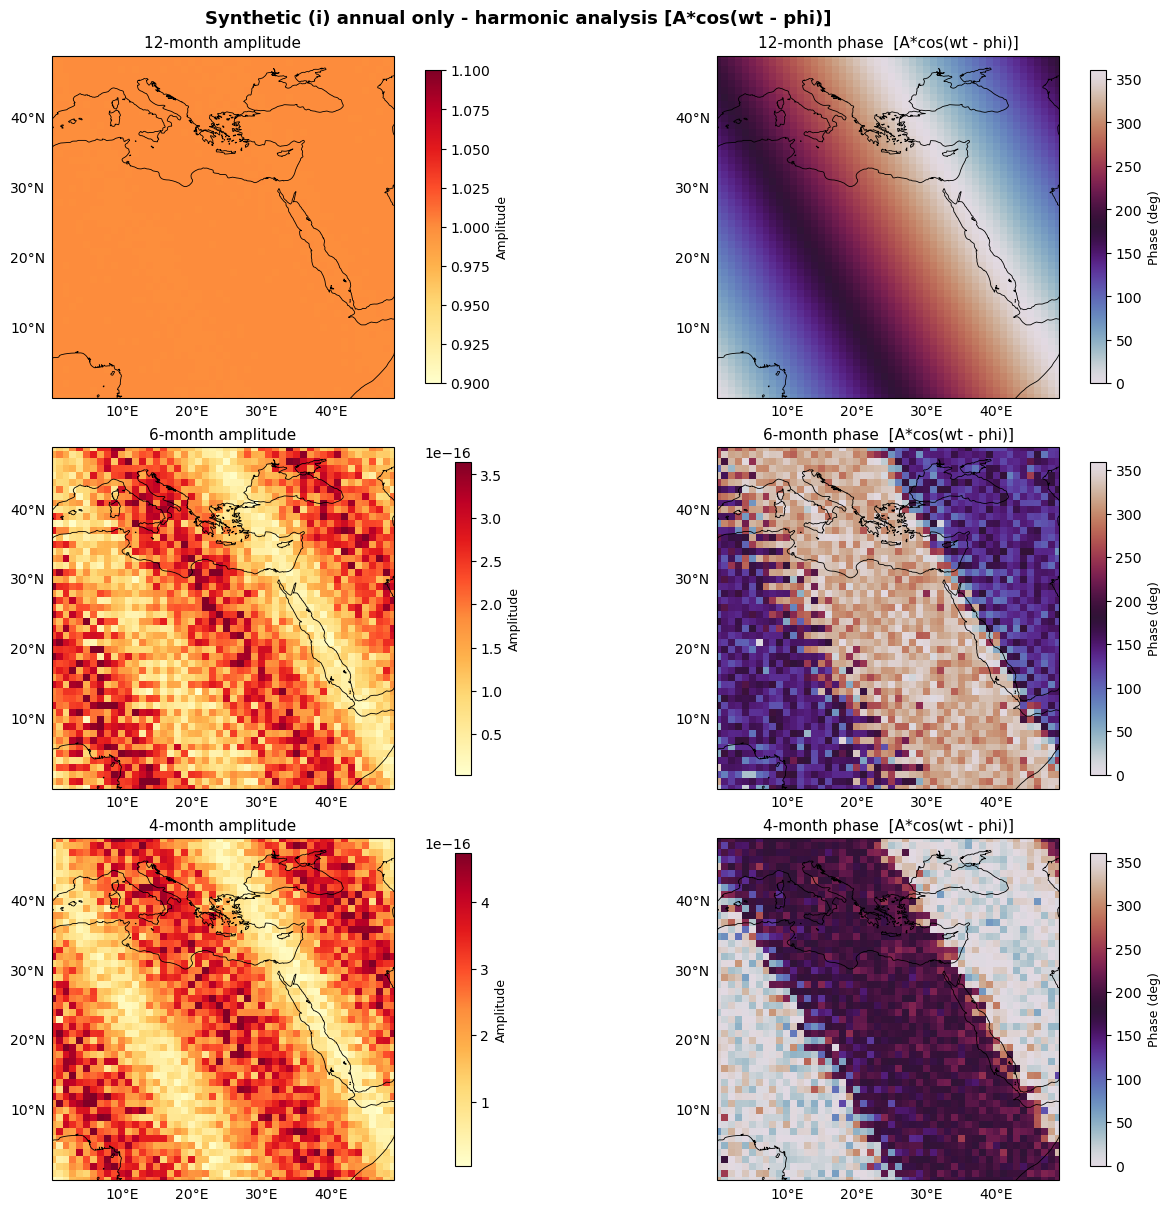

saved -> ../Figures\test_harmonics_annual.png


In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ext = [float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())]

def plot_harmonics(amp, pha, suptitle, fname):
    fig_h, axes_h = plt.subplots(
        len(periods), 2, figsize=(13, 4*len(periods)),
        subplot_kw={'projection': ccrs.PlateCarree()}, constrained_layout=True,
    )

    def harm_map(ax, data, cmap, label, title, vmin=None, vmax=None):
        ax.set_extent(ext, crs=ccrs.PlateCarree())
        # guarded coastlines - synthetic grid has none, but keep original call
        try:
            ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='k')
        except Exception:
            pass
        pcm = ax.pcolormesh(lons, lats, data, transform=ccrs.PlateCarree(),
                            cmap=cmap, vmin=vmin, vmax=vmax, shading='nearest')
        gl = ax.gridlines(draw_labels=True, linewidth=0, color='none')
        gl.top_labels = gl.right_labels = False
        cb = fig_h.colorbar(pcm, ax=ax, orientation='vertical', fraction=0.03, pad=0.06)
        cb.set_label(label, fontsize=9)
        ax.set_title(title, fontsize=11, pad=6)

    for r, P in enumerate(periods):
        harm_map(axes_h[r, 0], amp[P], 'YlOrRd', 'Amplitude',
                 f'{P}-month amplitude', vmax=np.nanpercentile(amp[P], 98))
        harm_map(axes_h[r, 1], pha[P], 'twilight', 'Phase (deg)',
                 f'{P}-month phase  [A*cos(wt - phi)]', vmin=0, vmax=360)

    fig_h.suptitle(suptitle, fontsize=13, fontweight='bold')
    out = os.path.join(OUT_DIR, fname)
    fig_h.savefig(out, dpi=120, bbox_inches='tight')
    plt.show()
    print('saved ->', out)

plot_harmonics(amp_i, pha_i,
               'Synthetic (i) annual only - harmonic analysis [A*cos(wt - phi)]',
               'test_harmonics_annual.png')

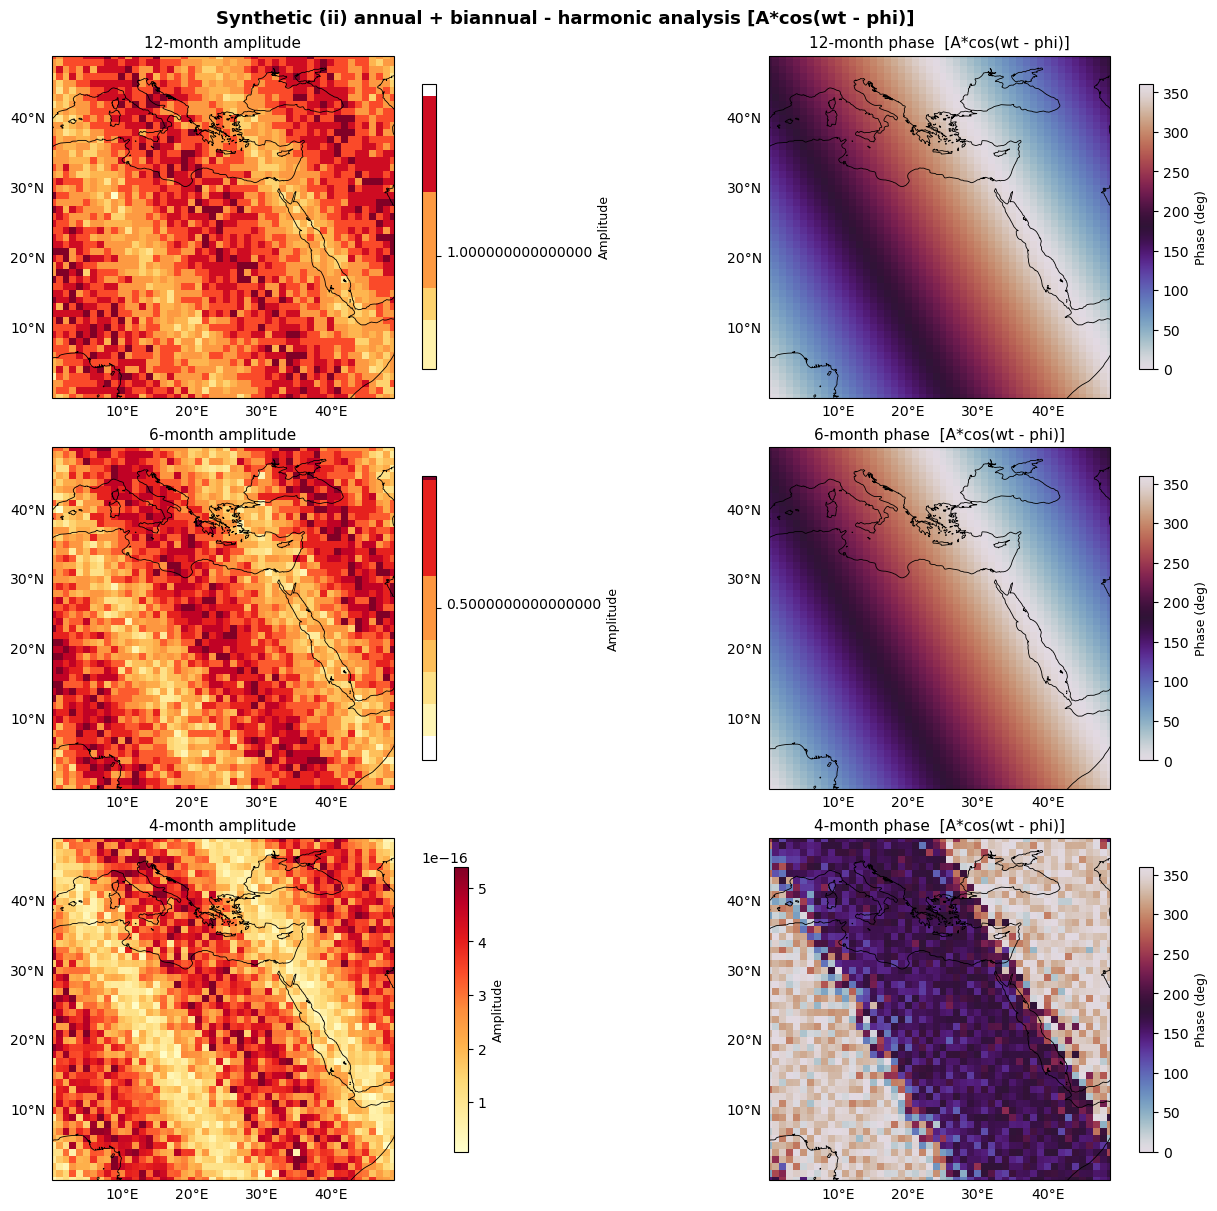

saved -> ../Figures\test_harmonics_annual_biannual.png


In [7]:
plot_harmonics(amp_ii, pha_ii,
               'Synthetic (ii) annual + biannual - harmonic analysis [A*cos(wt - phi)]',
               'test_harmonics_annual_biannual.png')

## Section E - Reconstruction, variance explained & metrics (from harmonic-cos.ipynb)

In [8]:
from scipy.stats import pearsonr

def reconstruct_and_score(detr_field, M, coef, amp, tag):
    months_ = pd.date_range(detr_field.time.values[0], detr_field.time.values[-1], freq='MS')
    n_lat_ = len(detr_field.lat); n_lon_ = len(detr_field.lon)

    recon = {}
    for kk, P in enumerate(periods):
        fitted = (M[:, 2*kk:2*kk+2] @ coef[2*kk:2*kk+2]).reshape(len(months_), n_lat_, n_lon_)
        recon[P] = xr.DataArray(fitted, dims=('time','lat','lon'), coords=detr_field.coords)
    recon_total = xr.DataArray((M @ coef).reshape(len(months_), n_lat_, n_lon_),
                               dims=('time','lat','lon'), coords=detr_field.coords)

    var_data = float(detr_field.var('time').sum())
    print(f'--- {tag} ---')
    print(f'Total variance : {var_data:.4e}')
    cum = 0.0
    for P in periods:
        frac = 100 * float(recon[P].var('time').sum()) / var_data
        cum += frac
        print(f'  {P:2d}-month harmonic : {frac:6.2f}%')
    print(f'  Combined         : {cum:6.2f}%')
    print(f'  Residual         : {100-cum:6.2f}%')

    y = detr_field.values.ravel(); y_hat = recon_total.values.ravel(); resid = y - y_hat
    ss_res = np.sum(resid**2); ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res/ss_tot; rmse = np.sqrt(np.mean(resid**2))
    r, _ = pearsonr(y, y_hat)
    print(f'  R^2 : {r2:.6f}   Pearson r : {r:.6f}   RMSE : {rmse:.3e}')
    print()
    return recon_total

rt_i  = reconstruct_and_score(da_i,  M_i,  coef_i,  amp_i,  'Dataset (i) annual only')
rt_ii = reconstruct_and_score(da_ii, M_ii, coef_ii, amp_ii, 'Dataset (ii) annual + biannual')

--- Dataset (i) annual only ---
Total variance : 1.2500e+03
  12-month harmonic : 100.00%
   6-month harmonic :   0.00%
   4-month harmonic :   0.00%
  Combined         : 100.00%
  Residual         :  -0.00%
  R^2 : 1.000000   Pearson r : 1.000000   RMSE : 3.705e-16

--- Dataset (ii) annual + biannual ---
Total variance : 1.5625e+03
  12-month harmonic :  80.00%
   6-month harmonic :  20.00%
   4-month harmonic :   0.00%
  Combined         : 100.00%
  Residual         :  -0.00%
  R^2 : 1.000000   Pearson r : 1.000000   RMSE : 4.385e-16



## Section F - Verdict: recovered vs injected

Automated pass/fail check comparing the decomposition output against the known ground truth.

In [9]:
def check(name, condition, detail):
    status = 'PASS' if condition else 'FAIL'
    print(f'  [{status}] {name}: {detail}')
    return condition

TOL = 1e-6
results = []

print('DATASET (i) - annual only')
results.append(check('annual amp = A12', np.allclose(amp_i[12], A12, atol=1e-4),
                     f'recovered {amp_i[12].mean():.6f} (injected {A12}), spread {amp_i[12].std():.2e}'))
results.append(check('biannual amp ~ 0', np.nanmax(amp_i[6]) < TOL,
                     f'max {np.nanmax(amp_i[6]):.2e}'))
results.append(check('4-month amp ~ 0', np.nanmax(amp_i[4]) < TOL,
                     f'max {np.nanmax(amp_i[4]):.2e}'))

# Phase: the algorithm recovers absolute phase only up to a global constant,
# so a correct plane-wave recovery means the *circular difference* between the
# recovered phase and the injected phi_true = k*proj is spatially CONSTANT.
# We check that this wrapped difference has ~zero spread (compared on the unit
# circle, which correctly ignores the 0/360 wrap-around).
phi_rec  = np.deg2rad(pha_i[12])
dphi     = np.angle(np.exp(1j * (phi_rec - phi_true)))   # wrapped diff in (-pi, pi]
# circular std of the difference: near 0 => recovered phase == k*proj + const
circ_std = np.sqrt(-2 * np.log(np.abs(np.mean(np.exp(1j * dphi)))))
results.append(check('annual phase == k*proj (up to const)', circ_std < 1e-4,
                     f'circular std of (phase_rec - k*proj) = {circ_std:.2e} rad'))

print('\nDATASET (ii) - annual + biannual')
results.append(check('annual amp = A12', np.allclose(amp_ii[12], A12, atol=1e-4),
                     f'recovered {amp_ii[12].mean():.6f} (injected {A12})'))
results.append(check('biannual amp = A6', np.allclose(amp_ii[6], A6, atol=1e-4),
                     f'recovered {amp_ii[6].mean():.6f} (injected {A6})'))
results.append(check('4-month amp ~ 0', np.nanmax(amp_ii[4]) < TOL,
                     f'max {np.nanmax(amp_ii[4]):.2e}'))

print('\n' + ('ALL CHECKS PASSED - algorithm is behaving correctly.'
              if all(results) else 'SOME CHECKS FAILED - inspect above.'))

DATASET (i) - annual only
  [PASS] annual amp = A12: recovered 1.000000 (injected 1.0), spread 3.12e-16
  [PASS] biannual amp ~ 0: max 4.73e-16
  [PASS] 4-month amp ~ 0: max 5.82e-16
  [PASS] annual phase == k*proj (up to const): circular std of (phase_rec - k*proj) = -0.00e+00 rad

DATASET (ii) - annual + biannual
  [PASS] annual amp = A12: recovered 1.000000 (injected 1.0)
  [PASS] biannual amp = A6: recovered 0.500000 (injected 0.5)
  [PASS] 4-month amp ~ 0: max 7.14e-16

ALL CHECKS PASSED - algorithm is behaving correctly.
